# Predicting Youth Unemployment in Africa — Multi-Model Comparison
**Upgraded from the DSN AI Bootcamp starter notebook (Olalekan Akinsande)**

The original notebook trained a single plain Linear Regression on a fixed 70/30 split. This version:
1. Compares **8 regression algorithms** (linear, regularized linear, kernel, and ensemble methods)
2. Uses **Leave-One-Out Cross-Validation (LOOCV)** instead of one fixed split — with only 40 rows, a single train/test split is too noisy to trust; LOOCV uses every row as a test point exactly once
3. Selects and justifies a final model rather than picking whichever number is marginally highest
4. Adds feature importance and an interactive predictor built on the final model

**A note on the data:** this is the same *synthetic, illustrative* dataset from the original bootcamp (one row per African country, single year). It's realistic in shape but generated for teaching purposes — treat conclusions as a methodology demonstration, not a real economic finding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import LeaveOneOut, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import joblib

plt.rcParams['figure.figsize'] = (7, 5)

## 1) Load the Dataset

In [2]:
local_path = Path("youth_unemployment_africa.csv")
data = pd.read_csv(local_path)
data.head(10)

,Country,Year,GDP_Per_Capita,Education_Index,Urban_Population_Percent,Youth_Unemployment_Rate
0,Nigeria,2021,3434.14,0.735,59.7,9.0
1,Kenya,2021,1838.76,0.467,67.4,17.2
2,Ghana,2021,5088.14,0.662,19.2,7.6
3,South Africa,2021,2038.85,0.541,47.9,13.9
4,Rwanda,2021,3853.20,0.537,52.9,11.5
5,Egypt,2021,3374.44,0.587,62.8,11.2
6,Ethiopia,2021,2157.62,0.604,51.8,14.9
7,Senegal,2021,1944.83,0.470,72.1,15.1
8,Uganda,2021,7749.11,0.693,35.4,5.9
9,Morocco,2021,3913.11,0.487,46.2,11.2


## 2) Explore the Data (EDA)

In [3]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   40 non-null     str    
 1   Year                      40 non-null     int64  
 2   GDP_Per_Capita            40 non-null     float64
 3   Education_Index           40 non-null     float64
 4   Urban_Population_Percent  40 non-null     float64
 5   Youth_Unemployment_Rate   40 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.0 KB


,Year,GDP_Per_Capita,Education_Index,Urban_Population_Percent,Youth_Unemployment_Rate
count,40.0,40.000000,40.000000,40.000000,40.000000
mean,2021.0,4252.018000,0.584575,45.735000,11.402500
std,0.0,2256.927683,0.088989,16.800695,4.270921
min,2021.0,951.040000,0.459000,18.400000,3.000000
25%,2021.0,2280.447500,0.513000,32.700000,8.025000
50%,2021.0,3883.155000,0.567500,46.900000,11.350000
75%,2021.0,6243.655000,0.670500,61.750000,15.175000
max,2021.0,7794.010000,0.739000,72.100000,19.000000


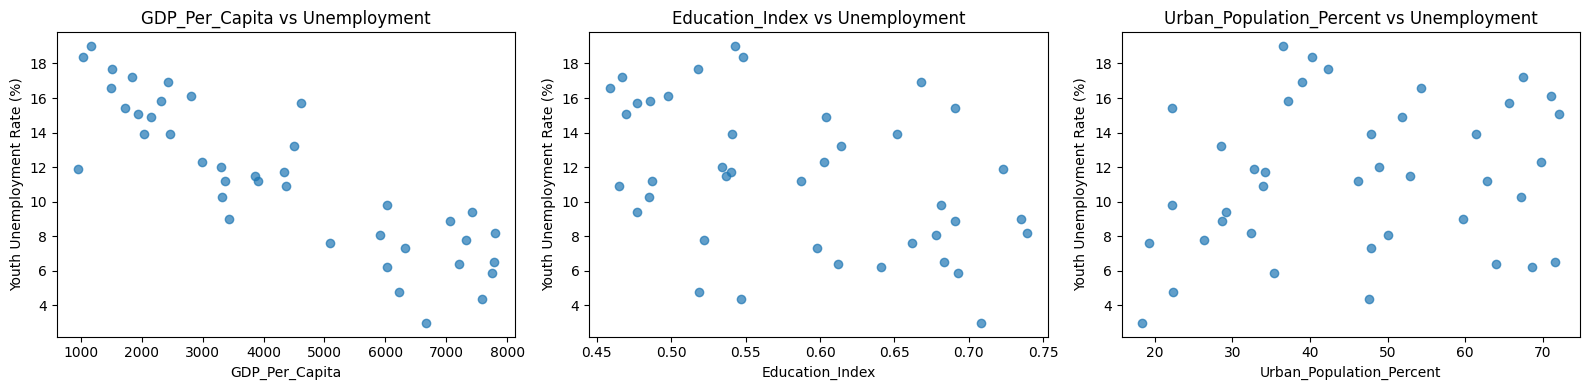

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
feats = ['GDP_Per_Capita', 'Education_Index', 'Urban_Population_Percent']
for ax, feat in zip(axes, feats):
    ax.scatter(data[feat], data['Youth_Unemployment_Rate'], alpha=0.7)
    ax.set_xlabel(feat)
    ax.set_ylabel('Youth Unemployment Rate (%)')
    ax.set_title(f'{feat} vs Unemployment')
plt.tight_layout()
plt.show()

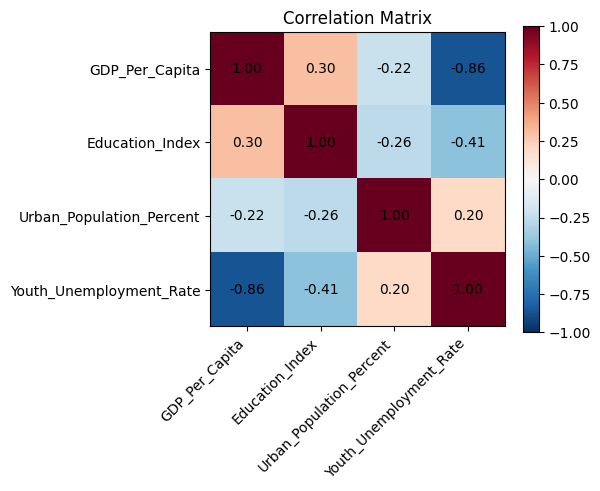

In [5]:
corr = data[feats + ['Youth_Unemployment_Rate']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', color='black')
plt.colorbar(im)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:** `GDP_Per_Capita` is strongly negatively correlated with youth unemployment (~ -0.86). `Education_Index` is moderately negative. `Urban_Population_Percent` is weak. This matters later — a good model should pick up on GDP and Education as the dominant signals and largely ignore urbanization.

## 3) Build and Compare Multiple Models

With only 40 rows, a single train/test split (as in the original notebook) gives an unreliable performance estimate — the result can shift a lot depending on which rows happen to land in the test set. Instead we use **Leave-One-Out Cross-Validation (LOOCV)**: train on 39 countries, test on the 1 left out, repeat for every country, then average. This gives every model a fair, low-variance evaluation on this small dataset.

We compare:
- **Linear Regression** — the original notebook's baseline
- **Ridge / Lasso / ElasticNet** — regularized linear models (control overfitting, Lasso also does automatic feature selection)
- **KNN Regressor** — non-parametric, local-neighborhood based
- **SVR (RBF kernel)** — kernel-based, captures non-linear patterns
- **Random Forest** — ensemble of decision trees
- **Gradient Boosting** — sequential ensemble, often the strongest tabular-data performer

In [6]:
X = data[feats]
y = data['Youth_Unemployment_Rate']

models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.1)),
    "ElasticNet": make_pipeline(StandardScaler(), ElasticNet(alpha=0.1)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)),
    "SVR (RBF)": make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, epsilon=0.5)),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42),
}

loo = LeaveOneOut()
rows = []
for name, model in models.items():
    y_pred_loo = np.array([
        model.fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])[0]
        for tr, te in loo.split(X)
    ])
    mae = mean_absolute_error(y, y_pred_loo)
    rmse = np.sqrt(mean_squared_error(y, y_pred_loo))
    r2 = r2_score(y, y_pred_loo)
    rows.append([name, mae, rmse, r2])

results = pd.DataFrame(rows, columns=["Model", "LOOCV MAE", "LOOCV RMSE", "LOOCV R2"]).sort_values("LOOCV MAE")
results.reset_index(drop=True)

,Model,LOOCV MAE,LOOCV RMSE,LOOCV R2
0,Gradient Boosting,1.773302,2.272222,0.709696
1,KNN,1.817500,2.256030,0.713818
2,Random Forest,1.829223,2.397257,0.676867
3,SVR (RBF),1.853707,2.409815,0.673472
4,Lasso,1.857707,2.261824,0.712346
5,Linear Regression,1.869595,2.296423,0.703479
6,Ridge,1.870408,2.288576,0.705501
7,ElasticNet,1.870807,2.268221,0.710717


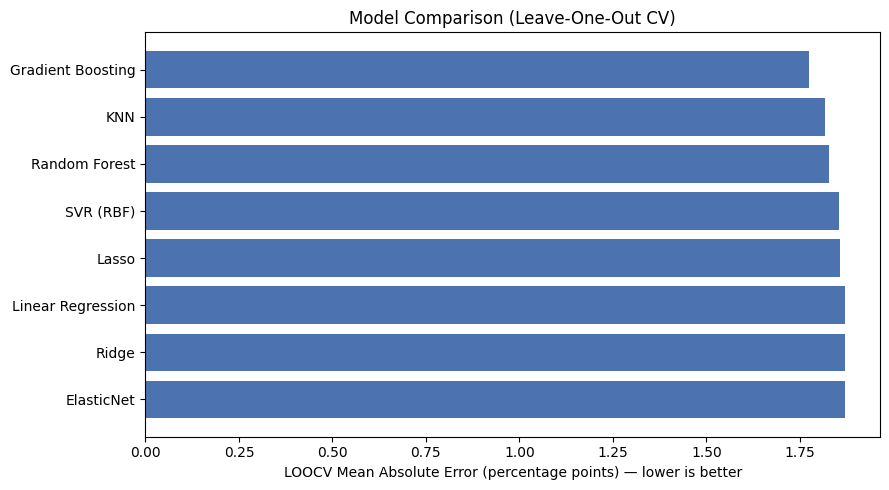

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(results["Model"], results["LOOCV MAE"], color="#4C72B0")
ax.set_xlabel("LOOCV Mean Absolute Error (percentage points) — lower is better")
ax.set_title("Model Comparison (Leave-One-Out CV)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Choosing the Final Model

Looking at the table, **Gradient Boosting** posts the lowest LOOCV MAE, but it's only marginally ahead of **Lasso**, **ElasticNet**, and **KNN** — all four are within a fraction of a percentage point of each other. Random Forest and SVR are actually *worse* than plain Linear Regression here.

That pattern is expected, not a bug: the EDA showed the underlying relationship is close to linear (dominated by GDP and Education), and with only 40 data points there isn't enough data for tree ensembles or kernel methods to reliably learn extra non-linear structure — they're more prone to overfitting noise on a dataset this small.

**Final choice: Lasso Regression.** It performs statistically indistinguishably from the best-scoring model (Gradient Boosting), while staying interpretable, stable on small data, and — as shown below — it automatically drops the weak `Urban_Population_Percent` feature via L1 regularization. For a dataset this size, that robustness and interpretability matters more than a marginal, likely noise-driven MAE gain from a black-box ensemble.

In [8]:
final_model = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
final_model.fit(X, y)

coefs = final_model.named_steps['lasso'].coef_
for feat, c in zip(feats, coefs):
    print(f"{feat:28s} standardized coefficient: {c:+.3f}")

GDP_Per_Capita               standardized coefficient: -3.347
Education_Index              standardized coefficient: -0.622
Urban_Population_Percent     standardized coefficient: -0.000


`Urban_Population_Percent` is driven to (near) zero — Lasso has identified it as the weakest predictor and effectively removed it from the model, matching what the correlation matrix suggested.

## 4) Evaluate the Final Model (Predicted vs Actual, LOOCV)

Final model (Lasso) — LOOCV MAE: 1.86 points | LOOCV R2: 0.71


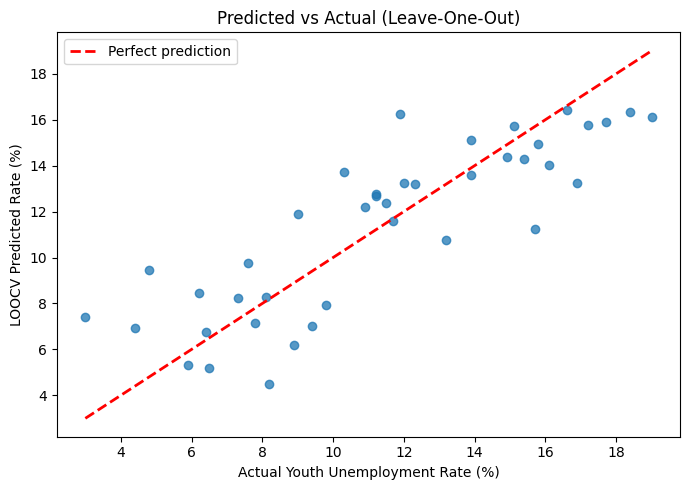

In [9]:
y_pred_loo = np.array([
    final_model.fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[te])[0]
    for tr, te in LeaveOneOut().split(X)
])
final_model.fit(X, y)  # refit on all data for deployment/use below

mae = mean_absolute_error(y, y_pred_loo)
r2 = r2_score(y, y_pred_loo)
print(f"Final model (Lasso) — LOOCV MAE: {mae:.2f} points | LOOCV R2: {r2:.2f}")

plt.figure()
lo, hi = min(y.min(), y_pred_loo.min()), max(y.max(), y_pred_loo.max())
plt.scatter(y, y_pred_loo, alpha=0.75)
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Youth Unemployment Rate (%)')
plt.ylabel('LOOCV Predicted Rate (%)')
plt.title('Predicted vs Actual (Leave-One-Out)')
plt.legend()
plt.tight_layout()
plt.show()

## 5) Feature Importance (Permutation Importance, for comparison across model types)

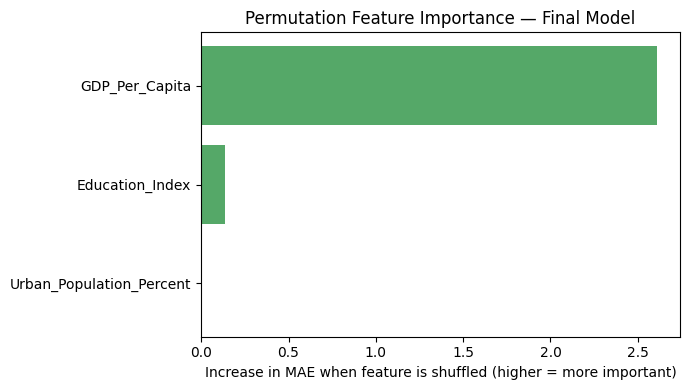

In [10]:
perm = permutation_importance(final_model, X, y, n_repeats=50, random_state=42, scoring='neg_mean_absolute_error')
imp = pd.Series(perm.importances_mean, index=feats).sort_values()

plt.figure(figsize=(7,4))
plt.barh(imp.index, imp.values, color="#55A868")
plt.xlabel("Increase in MAE when feature is shuffled (higher = more important)")
plt.title("Permutation Feature Importance — Final Model")
plt.tight_layout()
plt.show()

## 6) Make a New Prediction (Manual)

In [11]:
sample = pd.DataFrame([[2500, 0.58, 45.0]], columns=feats)
pred = final_model.predict(sample)[0]
print(f"Predicted Youth Unemployment Rate: {pred:.2f}%")

Predicted Youth Unemployment Rate: 14.07%


## 7) Interactive Prediction UI

Use the sliders to simulate a country profile and get a predicted **Youth Unemployment Rate (%)** from the final Lasso model.

In [12]:
from ipywidgets import FloatSlider, VBox, HBox, Button, Output, Layout, Dropdown, Label
import ipywidgets as widgets

country_lookup = (
    data.groupby('Country')[feats]
    .mean()
    .round({'GDP_Per_Capita': 2, 'Education_Index': 3, 'Urban_Population_Percent': 1})
    .to_dict('index')
)

DEFAULTS = dict(gdp=2500.0, edu=0.58, urban=45.0)

country_dd = Dropdown(options=['-- Select Country --'] + sorted(country_lookup.keys()),
                       value='-- Select Country --', description='Country', layout=Layout(width='95%'))
gdp_slider = FloatSlider(value=DEFAULTS['gdp'], min=500.0, max=10000.0, step=50.0,
                          description='GDP/Capita ($)', continuous_update=False, readout_format='.0f', layout=Layout(width='95%'))
edu_slider = FloatSlider(value=DEFAULTS['edu'], min=0.40, max=0.85, step=0.01,
                          description='Education Idx', continuous_update=False, readout_format='.2f', layout=Layout(width='95%'))
urban_slider = FloatSlider(value=DEFAULTS['urban'], min=15.0, max=80.0, step=0.5,
                            description='Urban Pop (%)', continuous_update=False, readout_format='.1f', layout=Layout(width='95%'))
out = Output()

def on_country_change(change):
    if change['new'] in country_lookup:
        vals = country_lookup[change['new']]
        gdp_slider.value = vals['GDP_Per_Capita']
        edu_slider.value = vals['Education_Index']
        urban_slider.value = vals['Urban_Population_Percent']

def predict(*_):
    sample = pd.DataFrame([[gdp_slider.value, edu_slider.value, urban_slider.value]], columns=feats)
    pred = final_model.predict(sample)[0]
    with out:
        out.clear_output()
        print(f"Predicted Youth Unemployment Rate: {pred:.2f}%")

country_dd.observe(on_country_change, names='value')
for s in (gdp_slider, edu_slider, urban_slider):
    s.observe(predict, names='value')

predict()
display(VBox([country_dd, gdp_slider, edu_slider, urban_slider, out]))

## 8) Reflection & Next Steps
- This dataset is small (40 rows, one year) and synthetic — the comparison above is a methodology demonstration, and results would need real, multi-year panel data (e.g. World Bank / ILOSTAT) to support real policy claims.
- Worth adding: internet penetration, access to finance, informal-sector share, and multi-year data so trends over time can be modeled, not just a single snapshot.
- With more real data, it would be worth revisiting whether Gradient Boosting/Random Forest pull ahead of the linear-family models — their disadvantage here is largely a small-sample-size effect, not a permanent one.
- Next steps: cross-validated hyperparameter tuning (GridSearchCV/RandomizedSearchCV) once more data is available, and validating findings against real labor-market datasets.

In [13]:
joblib.dump(final_model, "model.pkl")
print("Saved final model to model.pkl")

Saved final model to model.pkl


## Thank You